Columns in dataset: Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23

C:\Users\ZZSAS\AppData\Local\Temp\ipykernel_7980\3262308159.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette="Blues_d")


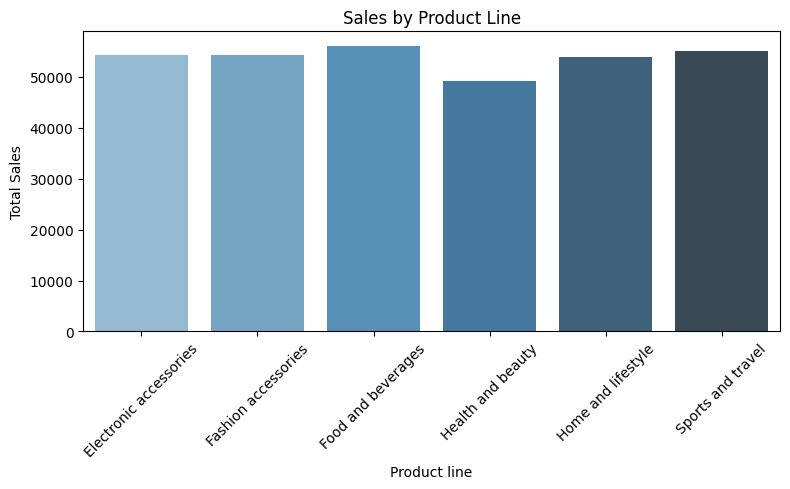

C:\Users\ZZSAS\AppData\Local\Temp\ipykernel_7980\3262308159.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_city.index, y=sales_by_city.values, palette="Oranges_d")


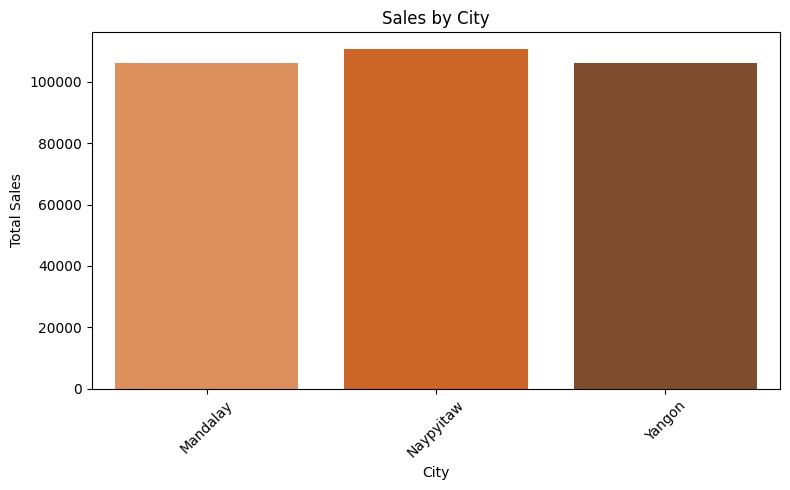

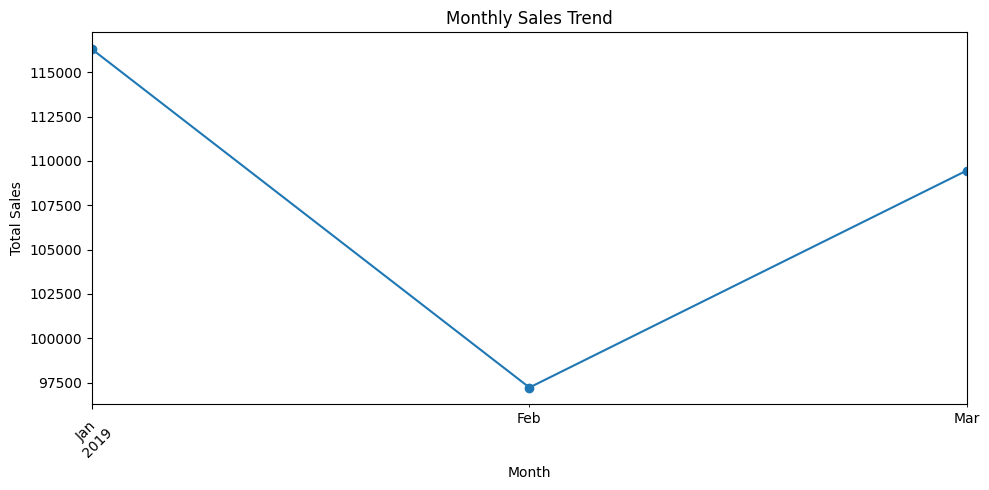

C:\Users\ZZSAS\AppData\Local\Temp\ipykernel_7980\3262308159.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, palette="Greens_d")


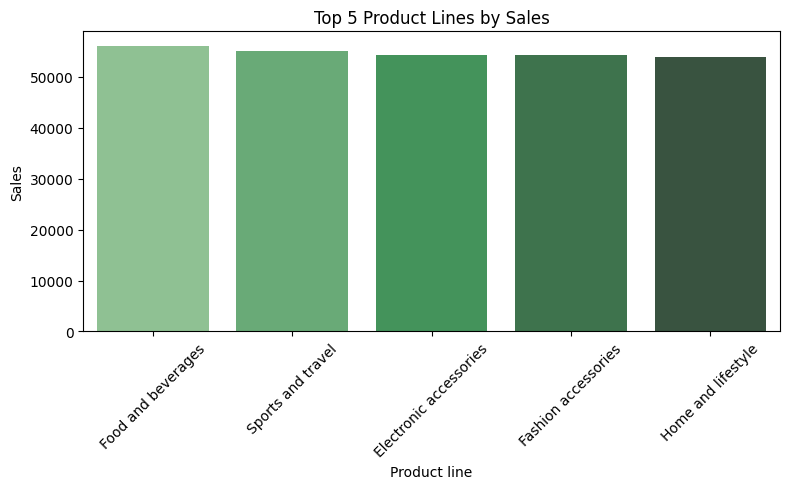

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/sales_analysis.csv")  

# Quick look at the data
print("Columns in dataset:", df.columns)
print(df.head())

df.columns = df.columns.str.strip()

print(df.isnull().sum())

df = df.drop_duplicates()
if 'Sales' in df.columns:
    df['Sales'] = df['Sales'].fillna(0)


# sales by category
sales_by_category = df.groupby("Product line")["Sales"].sum()
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette="Blues_d")
plt.title("Sales by Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/sales_by_category.png")
plt.show()


# sales by Region
sales_by_city = df.groupby("City")["Sales"].sum()
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_city.index, y=sales_by_city.values, palette="Oranges_d")
plt.title("Sales by City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/sales_by_city.png")
plt.show()

# monthly sales trend
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales'].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/monthly_sales_trend.png")
plt.show()


# top product by sale
top_products = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,5))
sns.barplot(x=top_products.index, y=top_products.values, palette="Greens_d")
plt.title("Top 5 Product Lines by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/top_products.png")
plt.show()